In [ ]:
!pip install mglearn

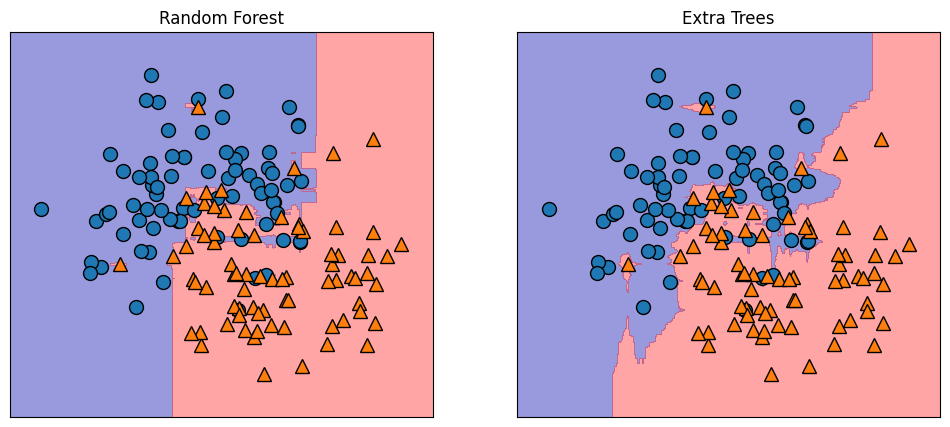

Random Forest Test Accuracy: 0.8
Extra Trees Test Accuracy: 0.86


In [ ]:
#sce1- implementation of bagging variants
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import mglearn

X, y = make_moons(n_samples=200, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

extra = ExtraTreesClassifier(n_estimators=100, random_state=0)
extra.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mglearn.plots.plot_2d_separator(forest, X_train, fill=True, ax=axes[0], alpha=.4)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=axes[0])
axes[0].set_title("Random Forest")

mglearn.plots.plot_2d_separator(extra, X_train, fill=True, ax=axes[1], alpha=.4)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=axes[1])
axes[1].set_title("Extra Trees")

plt.show()

print("Random Forest Test Accuracy:", forest.score(X_test, y_test))
print("Extra Trees Test Accuracy:", extra.score(X_test, y_test))

Model		Train Acc	Test Acc
GradientBoosting	1.000		0.965
AdaBoost		1.000		0.972


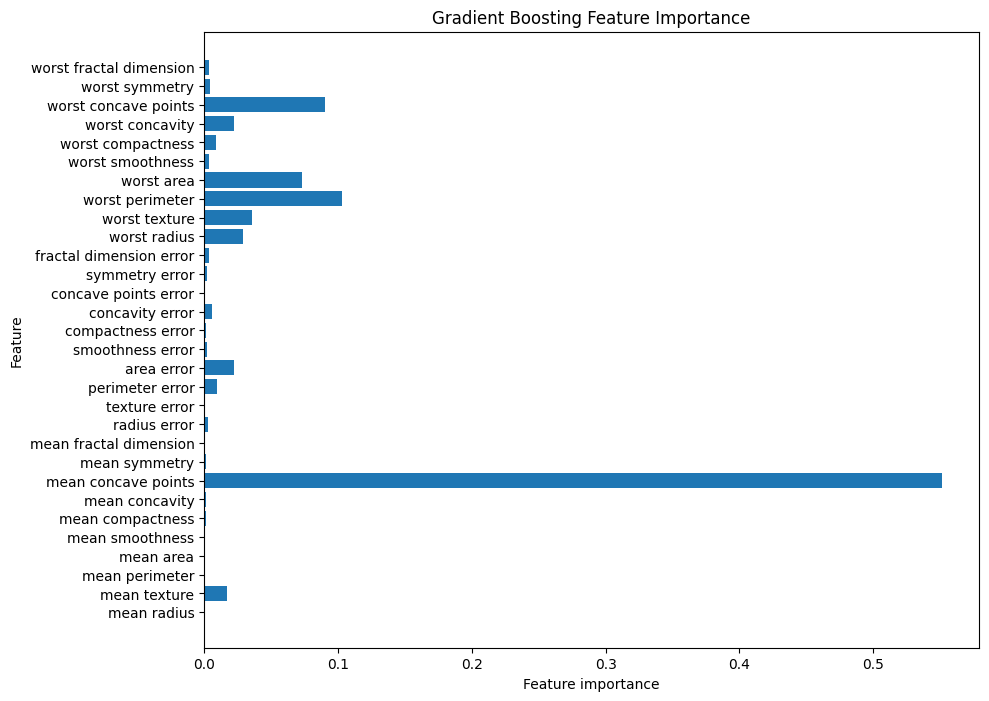

In [ ]:
#sce2- high precision diagnostic
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)

print("Model\t\tTrain Acc\tTest Acc")
print(f"GradientBoosting\t{gbrt.score(X_train, y_train):.3f}\t\t{gbrt.score(X_test, y_test):.3f}")
print(f"AdaBoost\t\t{ada.score(X_train, y_train):.3f}\t\t{ada.score(X_test, y_test):.3f}")

import numpy as np
plt.figure(figsize=(10, 8))
n_features = cancer.data.shape[1]
plt.barh(range(n_features), gbrt.feature_importances_, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.show()

In [ ]:
#sensitivity analysis
learning_rates = [0.01, 0.1, 1.0]
for lr in learning_rates:
    gbrt_lr = GradientBoostingClassifier(learning_rate=lr, random_state=0)
    gbrt_lr.fit(X_train, y_train)
    print(f"Learning Rate = {lr}")
    print(f"Train Acc: {gbrt_lr.score(X_train, y_train):.3f}")
    print(f"Test Acc: {gbrt_lr.score(X_test, y_test):.3f}\n")

Learning Rate = 0.01
Train Acc: 0.988
Test Acc: 0.958

Learning Rate = 0.1
Train Acc: 1.000
Test Acc: 0.965

Learning Rate = 1.0
Train Acc: 1.000
Test Acc: 0.951

